In [ ]:
import sys
from pathlib import Path

# Method 1: Use Path and parents
current_path = Path.cwd()
parent_dir = str(current_path.parent)  # Go up one level

# Method 2: If you're in a specific subdirectory
# and want to go up more levels
project_root = str(current_path.parent.parent)  # Go up two levels

# Add to path
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from tools.stock_prices import get_stock_prices

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from feature_extraction import add_state_column, get_trade_actions
from hybrid_model import HybridModel
from technical_indicator_classifier import TechnicalIndicatorClassifier
from collections import Counter
from sklearn.preprocessing import MinMaxScaler

In [3]:
stock = "UNTR.JK"
stock_prices = get_stock_prices(stock, "2023-01-01", "2025-12-31")
stock_prices["date"] = pd.to_datetime(stock_prices["date"])
add_state_column(stock_prices)

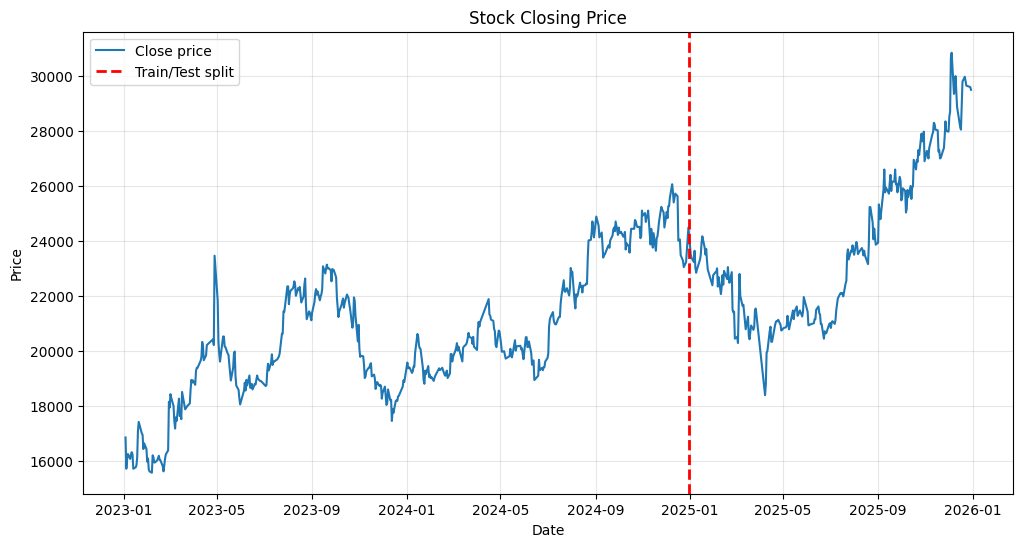

In [4]:
fig, ax = plt.subplots(figsize = (12, 6))

ax.plot(stock_prices["date"], stock_prices["close"], label = "Close price")

# Vertical split line
split_date = pd.to_datetime("2024-12-31")
ax.axvline(split_date, color = "red", linestyle = "--", linewidth = 2, label = "Train/Test split")
ax.set_title("Stock Closing Price")
ax.set_ylabel("Price")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha = 0.3)

plt.show()

In [5]:
split_date = pd.to_datetime("2024-12-31")
stock_prices_train = stock_prices[stock_prices["date"] <= split_date].reset_index(drop = True)
stock_prices_test = stock_prices[stock_prices["date"] > split_date].reset_index(drop = True)
stock_prices_test = pd.concat([stock_prices_train.tail(20), stock_prices_test], axis=0).reset_index(drop=True)
stock_prices_train

,symbol,date,open,high,low,close,volume,dividends,stock_splits,state
0,UNTR.JK,2023-01-03,16806.603391,16904.127202,16709.079580,16839.111328,2217400,0.0,0.0,"[0.1938, 0.5803, -0.5803, 0.1934, 84.3838]"
1,UNTR.JK,2023-01-04,16839.108667,16904.124531,15701.331055,15701.331055,8118200,0.0,0.0,"[-0.0, 0.3861, -6.7568, -6.7568, 266.1135]"
2,UNTR.JK,2023-01-05,15620.062858,16188.951724,15343.745409,16042.666016,10800300,0.0,0.0,"[-0.5176, 3.642, -1.769, 2.7055, 33.0381]"
3,UNTR.JK,2023-01-06,16140.189089,16383.998592,15928.887520,16237.712891,3662700,0.0,0.0,"[0.6079, 1.5106, -1.3092, 0.6042, -66.0871]"
4,UNTR.JK,2023-01-09,16253.966544,16383.998276,15782.601514,16058.918945,4614600,0.0,0.0,"[0.1001, 0.8, -2.9, -1.2, 25.989]"
...,...,...,...,...,...,...,...,...,...,...
470,UNTR.JK,2024-12-20,24049.092845,24117.673908,22997.516542,23477.583984,7273800,0.0,0.0,"[0.0, 0.2852, -4.3726, -2.3764, 161.4406]"
471,UNTR.JK,2024-12-23,23500.443379,23683.326206,22906.074188,23271.839844,4394000,0.0,0.0,"[0.0974, 0.7782, -2.5292, -0.9728, -39.5914]"
472,UNTR.JK,2024-12-24,23340.420924,23340.420924,22928.934561,23043.236328,1643700,0.0,0.0,"[0.2947, 0.0, -1.763, -1.2733, -62.5922]"
473,UNTR.JK,2024-12-27,23043.236313,23226.119141,22951.794899,23226.119141,1661000,0.0,0.0,"[-0.0, 0.7937, -0.3968, 0.7937, 1.0525]"


In [12]:
peek = 7
classifier = TechnicalIndicatorClassifier(peek = 7)
classifier.train(stock_prices_train)
result = classifier.predict(stock_prices_train)

In [13]:
y = get_trade_actions(stock_prices_train["close"], 7)
print(Counter(y))
print(Counter(result))
print(np.mean(y[1:] == result))

Counter({2: 375, 0: 37, 1: 37})
Counter({2: 347, 1: 53, 0: 48})
0.921875


In [14]:
results = model_trading_models(stock_prices_train, 3)
print(np.mean(results["nb"][1] == y))
print(np.mean(results["svm"][1] == y))
print(np.mean(results["dt"][1] == y))

NameError: name 'model_trading_models' is not defined

In [ ]:
from collections import Counter
print(Counter(results["nb"][1]))
print(Counter(results["svm"][1]))
print(Counter(results["dt"][1]))
print(Counter(y))

Counter({2: 211, 0: 181, 1: 61})
Counter({2: 205, 0: 141, 1: 107})
Counter({2: 209, 1: 144, 0: 100})
Counter({2: 355, 1: 49, 0: 49})
